# COVID-19 Case Analysis

## Project Overview

This project analyzes COVID-19 case and death trends across selected countries over time.

### Objectives

* Analyze the growth of COVID-19 cases.
* Examine daily death trends.
* Compare total cases across countries.
* Compare total deaths across countries.
* Visualize COVID-19 trends using time-series and bar charts.

### Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Jupyter Notebook


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
%pip install pandas numpy matplotlib seaborn

  Using cached matplotlib-3.11.2-cp311-cp311-win_amd64.whl (9.3 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 1.6/1.6 MB 185.4 kB/s eta 0:00:00
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl (70 kB)
     ------------------------------------ 126.4/126.4 kB 929.4 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd

df = pd.read_csv("../Dataset/covid_data.csv")

print("Dataset loaded successfully!")
print(df.head())
print(df.shape)

Dataset loaded successfully!
         date     location  new_cases  new_deaths  total_cases  total_deaths
0  2020-02-25  Afghanistan        NaN         NaN            1           NaN
1  2020-02-26  Afghanistan        0.0         NaN            1           NaN
2  2020-02-27  Afghanistan        0.0         NaN            1           NaN
3  2020-02-28  Afghanistan        0.0         NaN            1           NaN
4  2020-02-29  Afghanistan        0.0         NaN            1           NaN
(126, 6)


In [2]:
# Check dataset information

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumber of Countries:")
print(df["location"].nunique())

print("\nDate Range:")
print(df["date"].min(), "to", df["date"].max())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          126 non-null    object 
 1   location      126 non-null    object 
 2   new_cases     121 non-null    float64
 3   new_deaths    27 non-null     float64
 4   total_cases   126 non-null    int64  
 5   total_deaths  31 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 6.0+ KB
None

Missing Values:
date             0
location         0
new_cases        5
new_deaths      99
total_cases      0
total_deaths    95
dtype: int64

Number of Countries:
5

Date Range:
2020-01-25 to 2020-03-17


In [7]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Replace missing daily cases and deaths with 0
df["new_cases"] = df["new_cases"].fillna(0)
df["new_deaths"] = df["new_deaths"].fillna(0)

# Replace missing total deaths with 0
df["total_deaths"] = df["total_deaths"].fillna(0)

print("Data cleaning completed!")
print(df.isnull().sum())

Data cleaning completed!
date            0
location        0
new_cases       0
new_deaths      0
total_cases     0
total_deaths    0
dtype: int64


In [4]:
# Calculate global daily total cases
global_cases = df.groupby("date")["new_cases"].sum().reset_index()

# Plot global daily new cases
plt.figure(figsize=(10, 5))

plt.plot(global_cases["date"], global_cases["new_cases"], linewidth=2)

plt.title("Global Daily New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../Images/global_daily_cases.png", dpi=300)
plt.show()

NameError: name 'plt' is not defined

In [10]:
df["date"] = pd.to_datetime(df["date"])

df["new_cases"] = df["new_cases"].fillna(0)
df["new_deaths"] = df["new_deaths"].fillna(0)
df["total_deaths"] = df["total_deaths"].fillna(0)

print("Data cleaning completed!")
print(df.isnull().sum())

Data cleaning completed!
date            0
location        0
new_cases       0
new_deaths      0
total_cases     0
total_deaths    0
dtype: int64


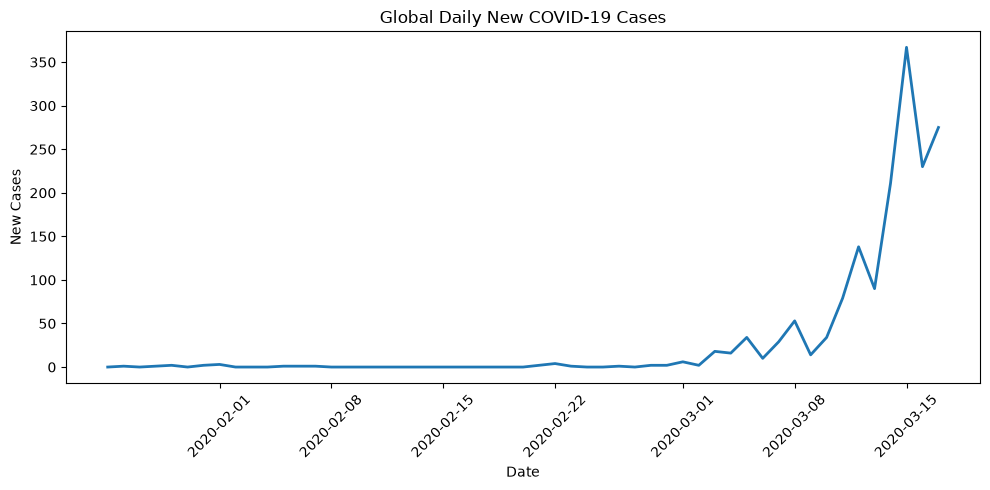

In [11]:
# Calculate global daily new cases
global_cases = df.groupby("date")["new_cases"].sum().reset_index()

# Create the graph
plt.figure(figsize=(10, 5))

plt.plot(
    global_cases["date"],
    global_cases["new_cases"],
    linewidth=2
)

plt.title("Global Daily New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.xticks(rotation=45)

plt.tight_layout()

# Save the graph
plt.savefig("../Images/global_daily_cases.png", dpi=300)

plt.show()

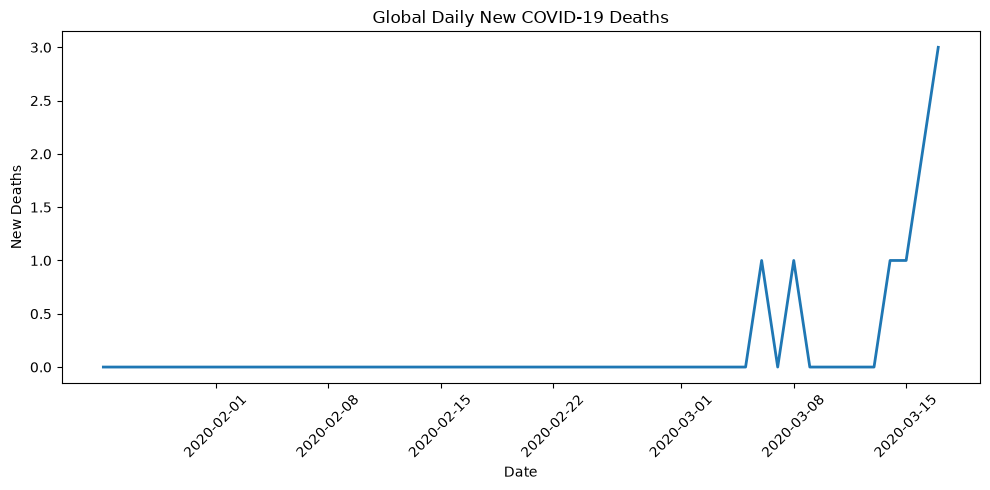

In [12]:
# Calculate global daily deaths
global_deaths = df.groupby("date")["new_deaths"].sum().reset_index()

# Create the graph
plt.figure(figsize=(10, 5))

plt.plot(
    global_deaths["date"],
    global_deaths["new_deaths"],
    linewidth=2
)

plt.title("Global Daily New COVID-19 Deaths")
plt.xlabel("Date")
plt.ylabel("New Deaths")
plt.xticks(rotation=45)

plt.tight_layout()

# Save the graph
plt.savefig("../Images/global_daily_deaths.png", dpi=300)

plt.show()

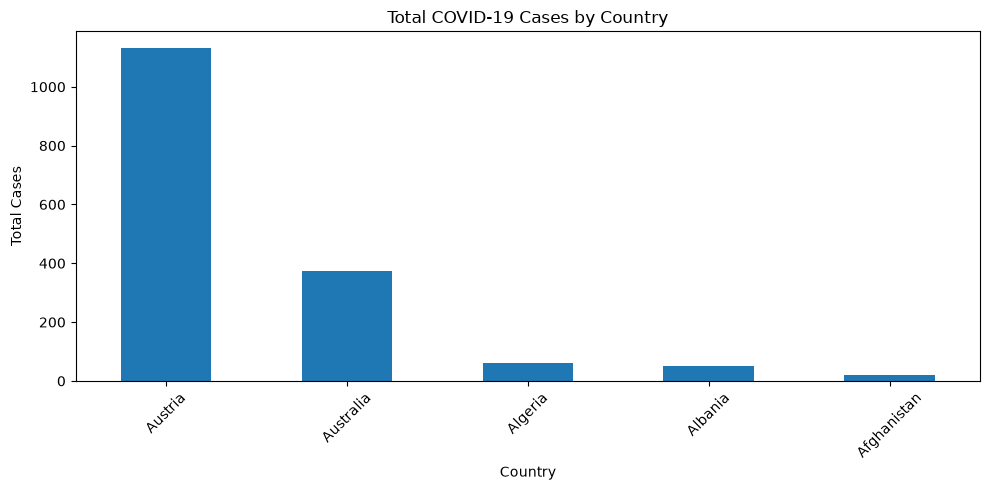

In [13]:
# Calculate total cases by country
country_cases = (
    df.groupby("location")["total_cases"]
    .max()
    .sort_values(ascending=False)
)

# Create the bar chart
plt.figure(figsize=(10, 5))

country_cases.plot(kind="bar")

plt.title("Total COVID-19 Cases by Country")
plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)

plt.tight_layout()

# Save the graph
plt.savefig("../Images/country_total_cases.png", dpi=300)

plt.show()

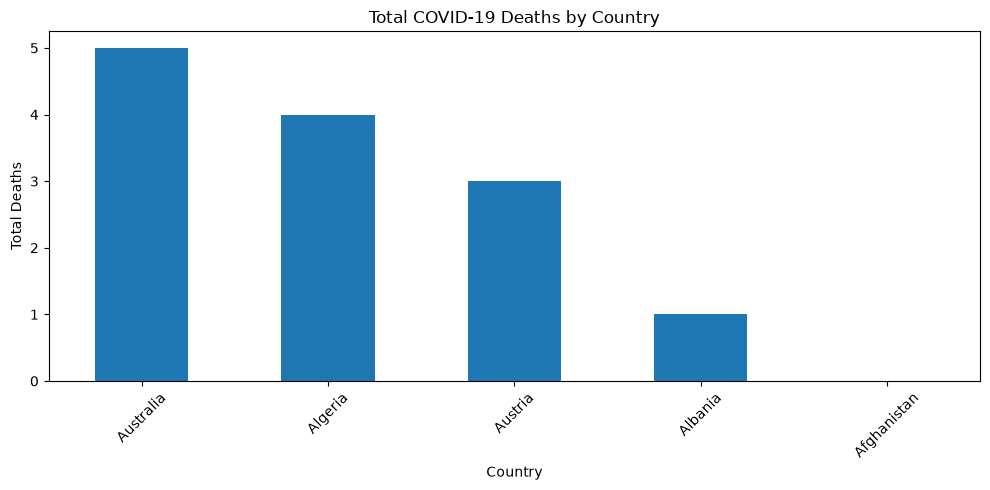

In [14]:
# Calculate total deaths by country
country_deaths = (
    df.groupby("location")["total_deaths"]
    .max()
    .sort_values(ascending=False)
)

# Create the bar chart
plt.figure(figsize=(10, 5))

country_deaths.plot(kind="bar")

plt.title("Total COVID-19 Deaths by Country")
plt.xlabel("Country")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45)

plt.tight_layout()

# Save the graph
plt.savefig("../Images/country_total_deaths.png", dpi=300)

plt.show()

In [15]:
# Key statistics for the project

print("COVID-19 CASE ANALYSIS")
print("=" * 40)

print("Total Cases Recorded:",
      int(df["total_cases"].max()))

print("Total Deaths Recorded:",
      int(df["total_deaths"].max()))

print("Countries Analysed:",
      df["location"].nunique())

print("Analysis Period:",
      df["date"].min().date(),
      "to",
      df["date"].max().date())

print("\nHighest Total Cases by Country:")
print(country_cases.head())

print("\nHighest Total Deaths by Country:")
print(country_deaths.head())

COVID-19 CASE ANALYSIS
Total Cases Recorded: 1132
Total Deaths Recorded: 5
Countries Analysed: 5
Analysis Period: 2020-01-25 to 2020-03-17

Highest Total Cases by Country:
location
Austria        1132
Australia       375
Algeria          60
Albania          51
Afghanistan      21
Name: total_cases, dtype: int64

Highest Total Deaths by Country:
location
Australia      5.0
Algeria        4.0
Austria        3.0
Albania        1.0
Afghanistan    0.0
Name: total_deaths, dtype: float64


## Conclusion

The COVID-19 case analysis examined the spread of COVID-19 across different countries over time. The analysis used daily case and death data to identify changes in case growth and mortality trends.

The visualizations show how COVID-19 cases and deaths changed during the analysed period and provide a comparison of the impact across countries. Time-series analysis helped identify the progression of the outbreak, while country-level comparisons highlighted differences in reported cases and deaths.

This project demonstrates the use of Python, Pandas, Matplotlib, and Seaborn for data cleaning, time-series analysis, visualization, and interpretation of real-world public health data.